#Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

#Loading The Datasets

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Checking the shape of the dataset

In [3]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


#Display Images

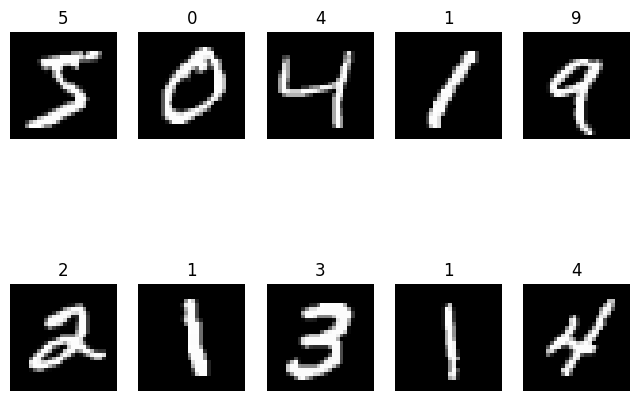

In [4]:
plt.figure(figsize=(8,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap = 'gray')
  plt.title(y_train[i])
  plt.axis('off')
plt.savefig("sample_images.png")
plt.show()

#Normalizing the Data

In [5]:
x_train = x_train/255.0
x_test = x_test/255.0

#Build Neural Network

In [6]:
model = Sequential([Flatten(input_shape=(28,28)),
                    Dense(128, activation = 'relu'),
                    Dense(64, activation = 'relu'),
                    Dense(10, activation = 'softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#Model Summary

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#Compile the model

In [8]:
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

#Training the model

In [9]:
history = model.fit( x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9212 - loss: 0.2651 - val_accuracy: 0.9596 - val_loss: 0.1367
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9653 - loss: 0.1145 - val_accuracy: 0.9676 - val_loss: 0.1100
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9758 - loss: 0.0783 - val_accuracy: 0.9685 - val_loss: 0.1098
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0594 - val_accuracy: 0.9688 - val_loss: 0.1029
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9864 - loss: 0.0448 - val_accuracy: 0.9715 - val_loss: 0.1028
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9885 - loss: 0.0369 - val_accuracy: 0.9718 - val_loss: 0.0996
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9904 - loss: 0.0295 - val_accuracy: 0.9753 - val_loss: 0.1016
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9910 - loss: 0.0275 - 

#Evaluating the model

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuaracy", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0942
Test Accuaracy 0.9757999777793884


#Graph 1(Accuracy Graph)

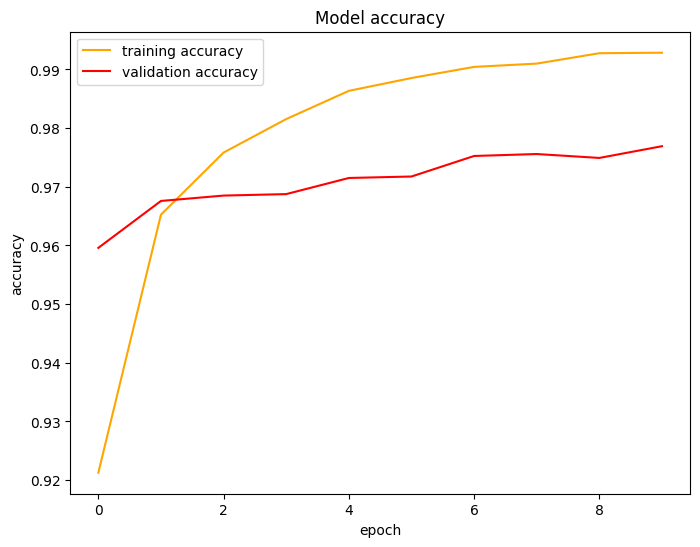

In [17]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label = 'training accuracy', color='orange')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy', color= 'red')
plt.title("Model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.savefig("accuracy_graph.png")
plt.show()

#Graph 2 (Loss Graph)

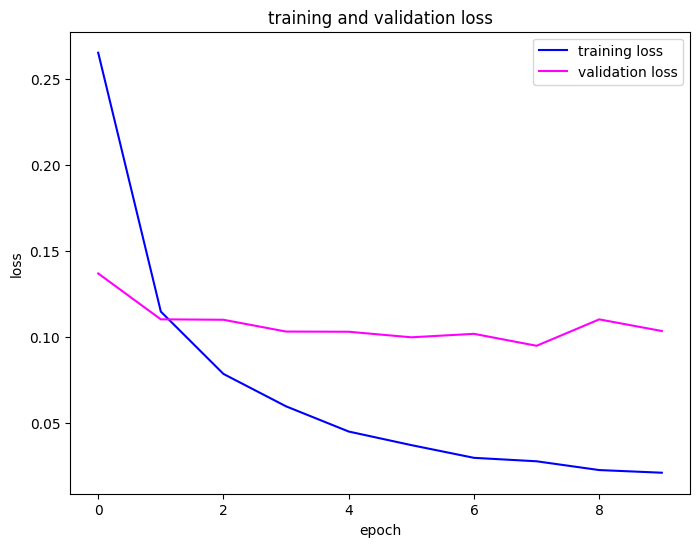

In [19]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label = 'training loss', color = 'blue')
plt.plot(history.history['val_loss'], label = 'validation loss', color = 'magenta')
plt.title("training and validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.savefig("loss_graph.png")
plt.show()

#Model Predictions

In [12]:
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#Confusion Matrix

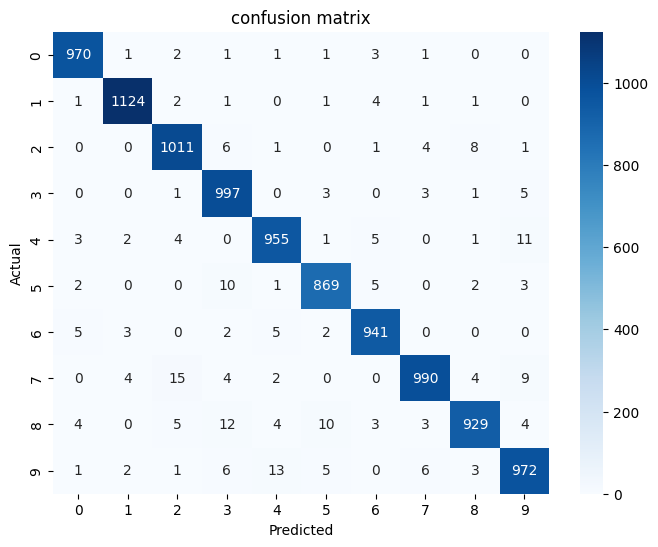

In [13]:
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix")
plt.savefig("Confusion_matrix.png")
plt.show()

#Classification Report

In [20]:
print(classification_report(y_test, predicted_classes))
plt.savefig("Classification_report.png")

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.96      0.99      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



<Figure size 640x480 with 0 Axes>

#Saving the Model

In [15]:
model.save("trained_model.keras")